In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
df = pd.read_csv("../data/outputs/provider_month_NY_individual.csv")
df

,billing_provider_npi,month,paid_t,claims_t,hcpcs_count_t,paid_per_claim_t,top_code_paid_share,top_3_code_paid_share,hcpcs_entropy,hcpcs_hhi,label,excldate
0,1003001371,2018-01-01,852.73,38,2,22.440263,1.0,1.0,0.0,1.0,0,NaN
1,1003001371,2018-02-01,494.70,26,1,19.026923,1.0,1.0,0.0,1.0,0,NaN
2,1003001371,2018-03-01,948.09,38,1,24.949737,1.0,1.0,0.0,1.0,0,NaN
3,1003001371,2018-04-01,307.88,18,1,17.104444,1.0,1.0,0.0,1.0,0,NaN
4,1003001371,2018-05-01,948.09,44,1,21.547500,1.0,1.0,0.0,1.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1010964,1992996912,2019-11-01,192.80,17,1,11.341176,1.0,1.0,0.0,1.0,0,NaN
1010965,1992996912,2019-12-01,205.40,17,1,12.082353,1.0,1.0,0.0,1.0,0,NaN
1010966,1992996912,2020-01-01,1283.08,16,1,80.192500,1.0,1.0,0.0,1.0,0,NaN
1010967,1992996912,2020-09-01,328.75,12,1,27.395833,1.0,1.0,0.0,1.0,0,NaN


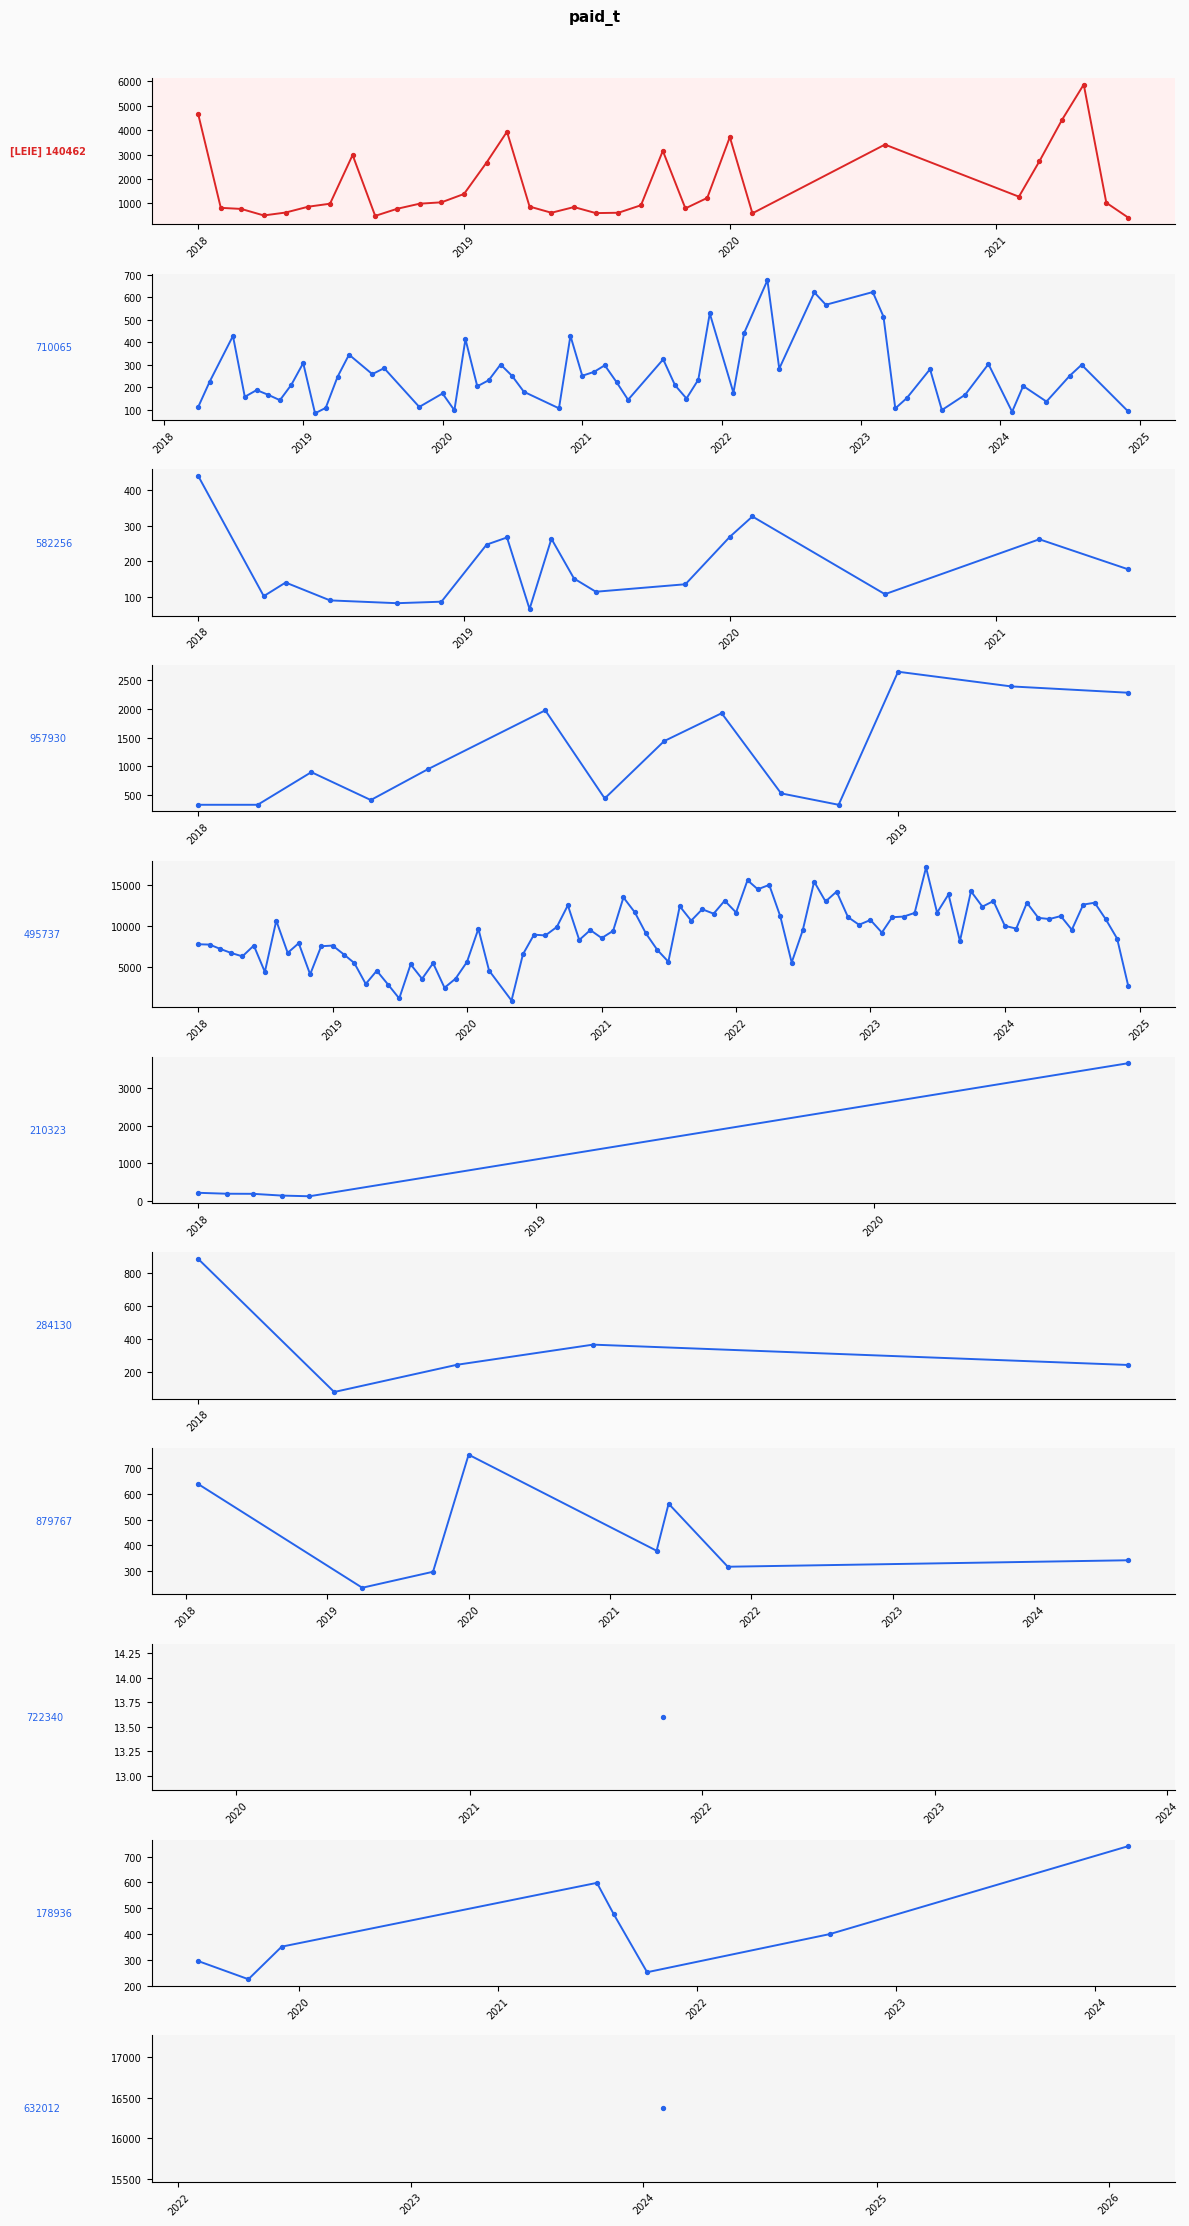

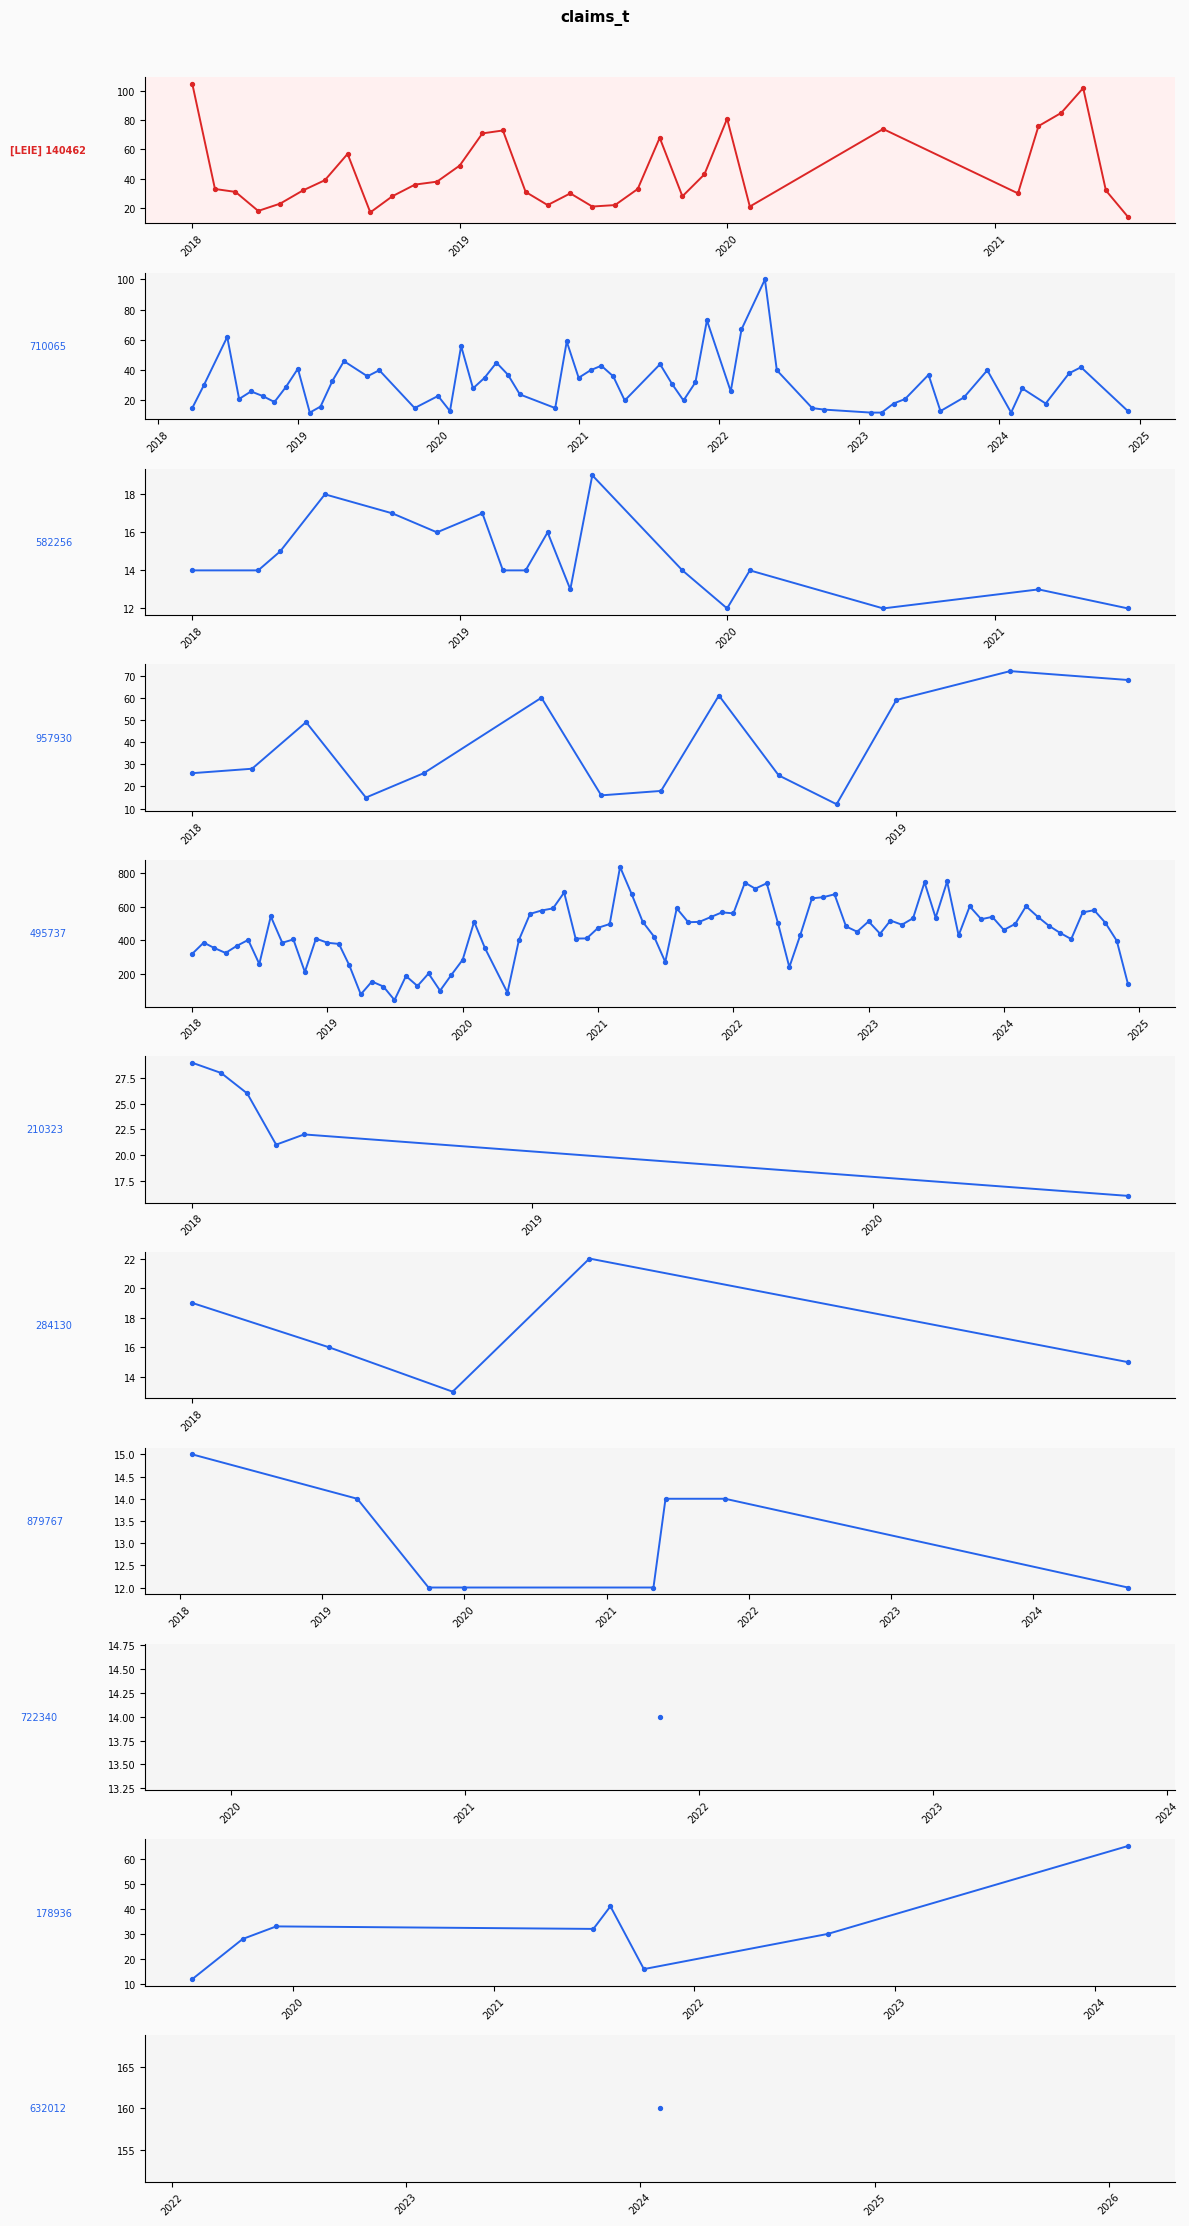

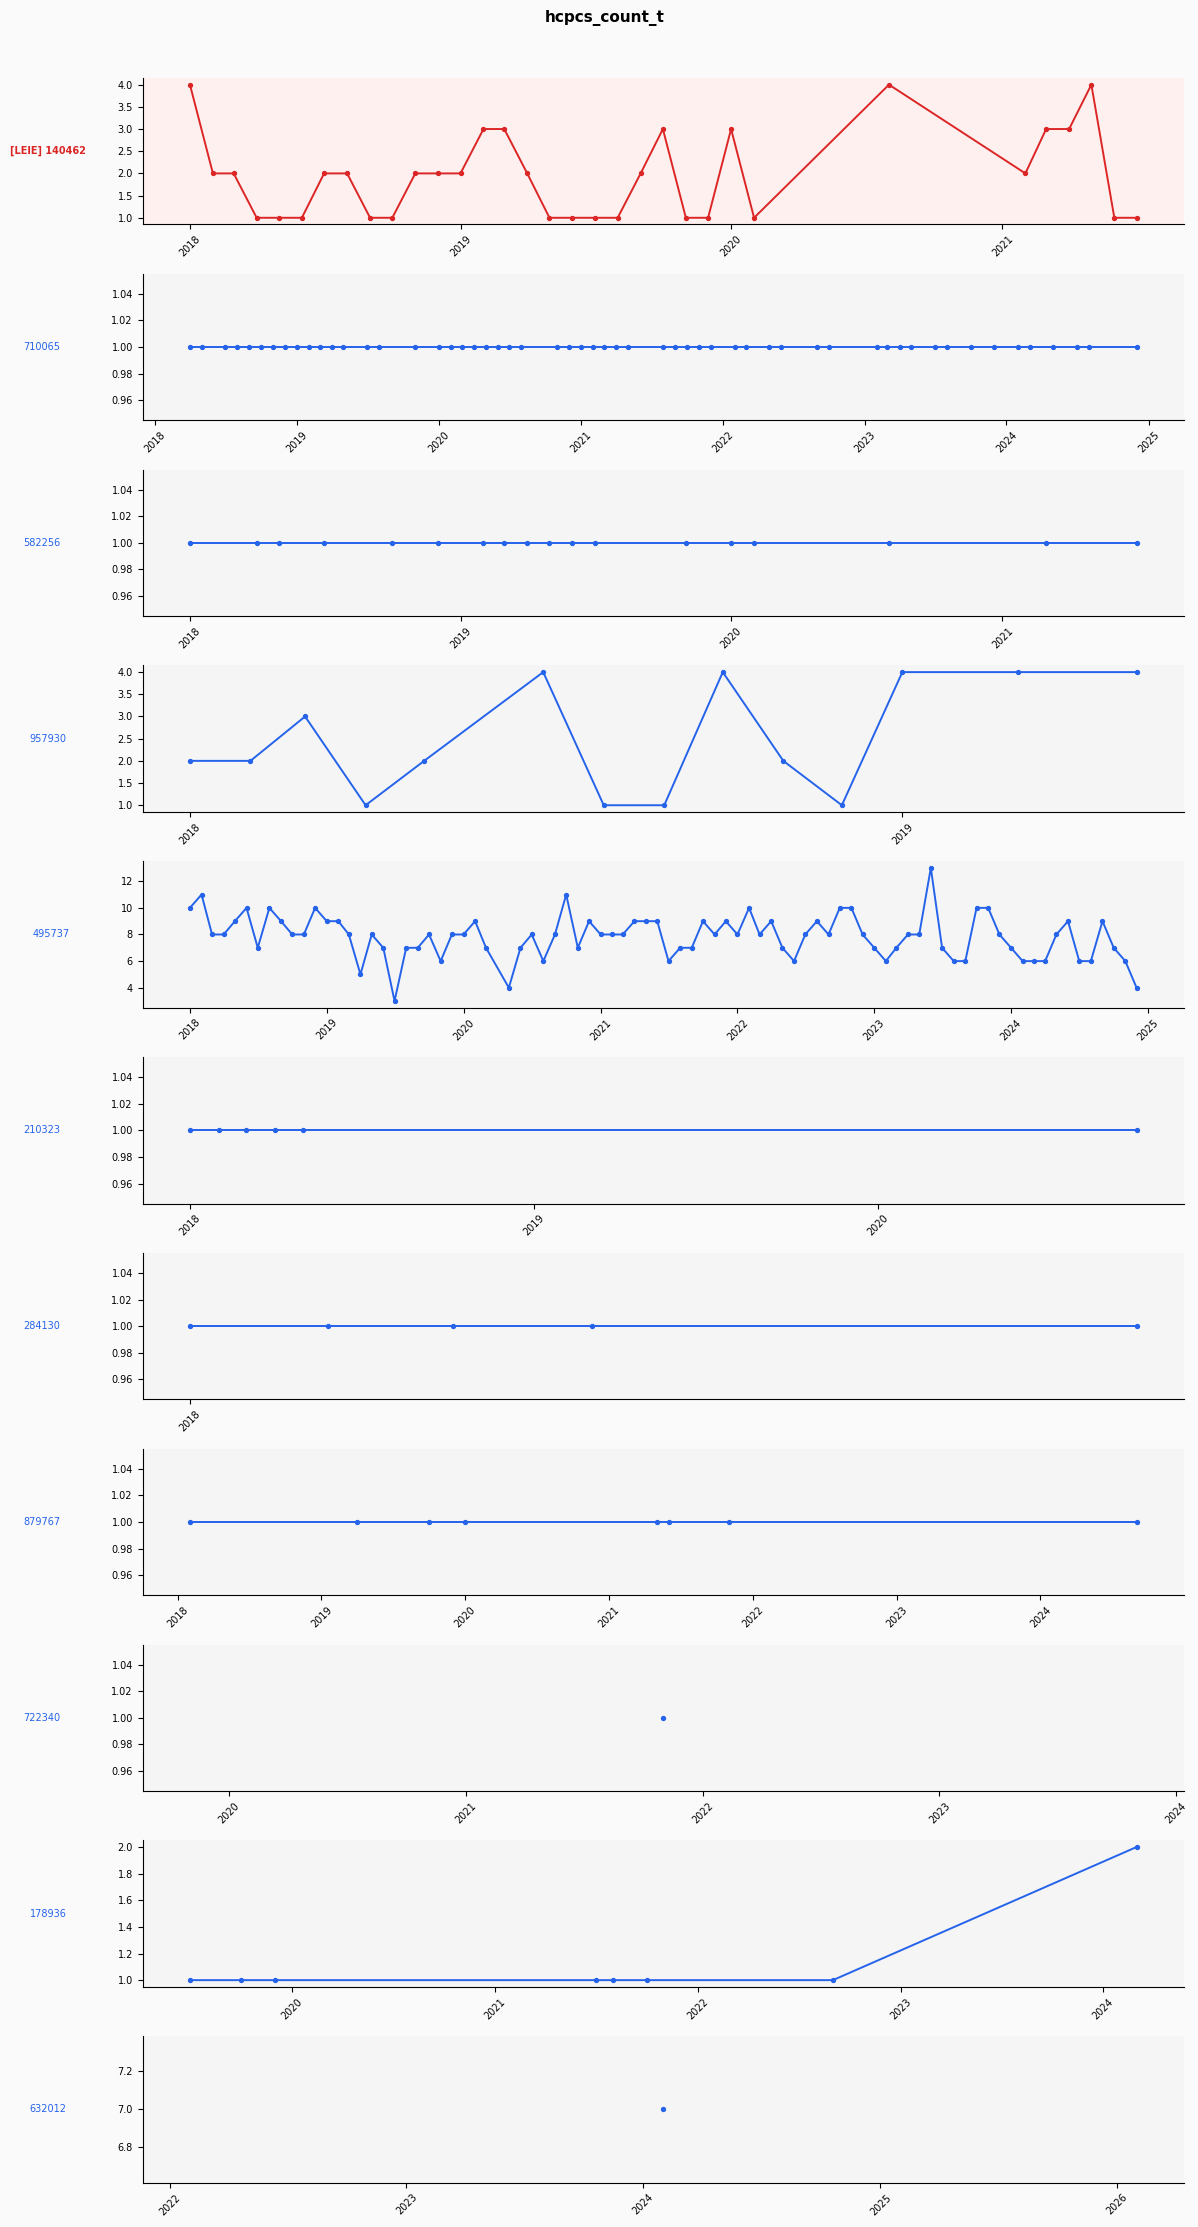

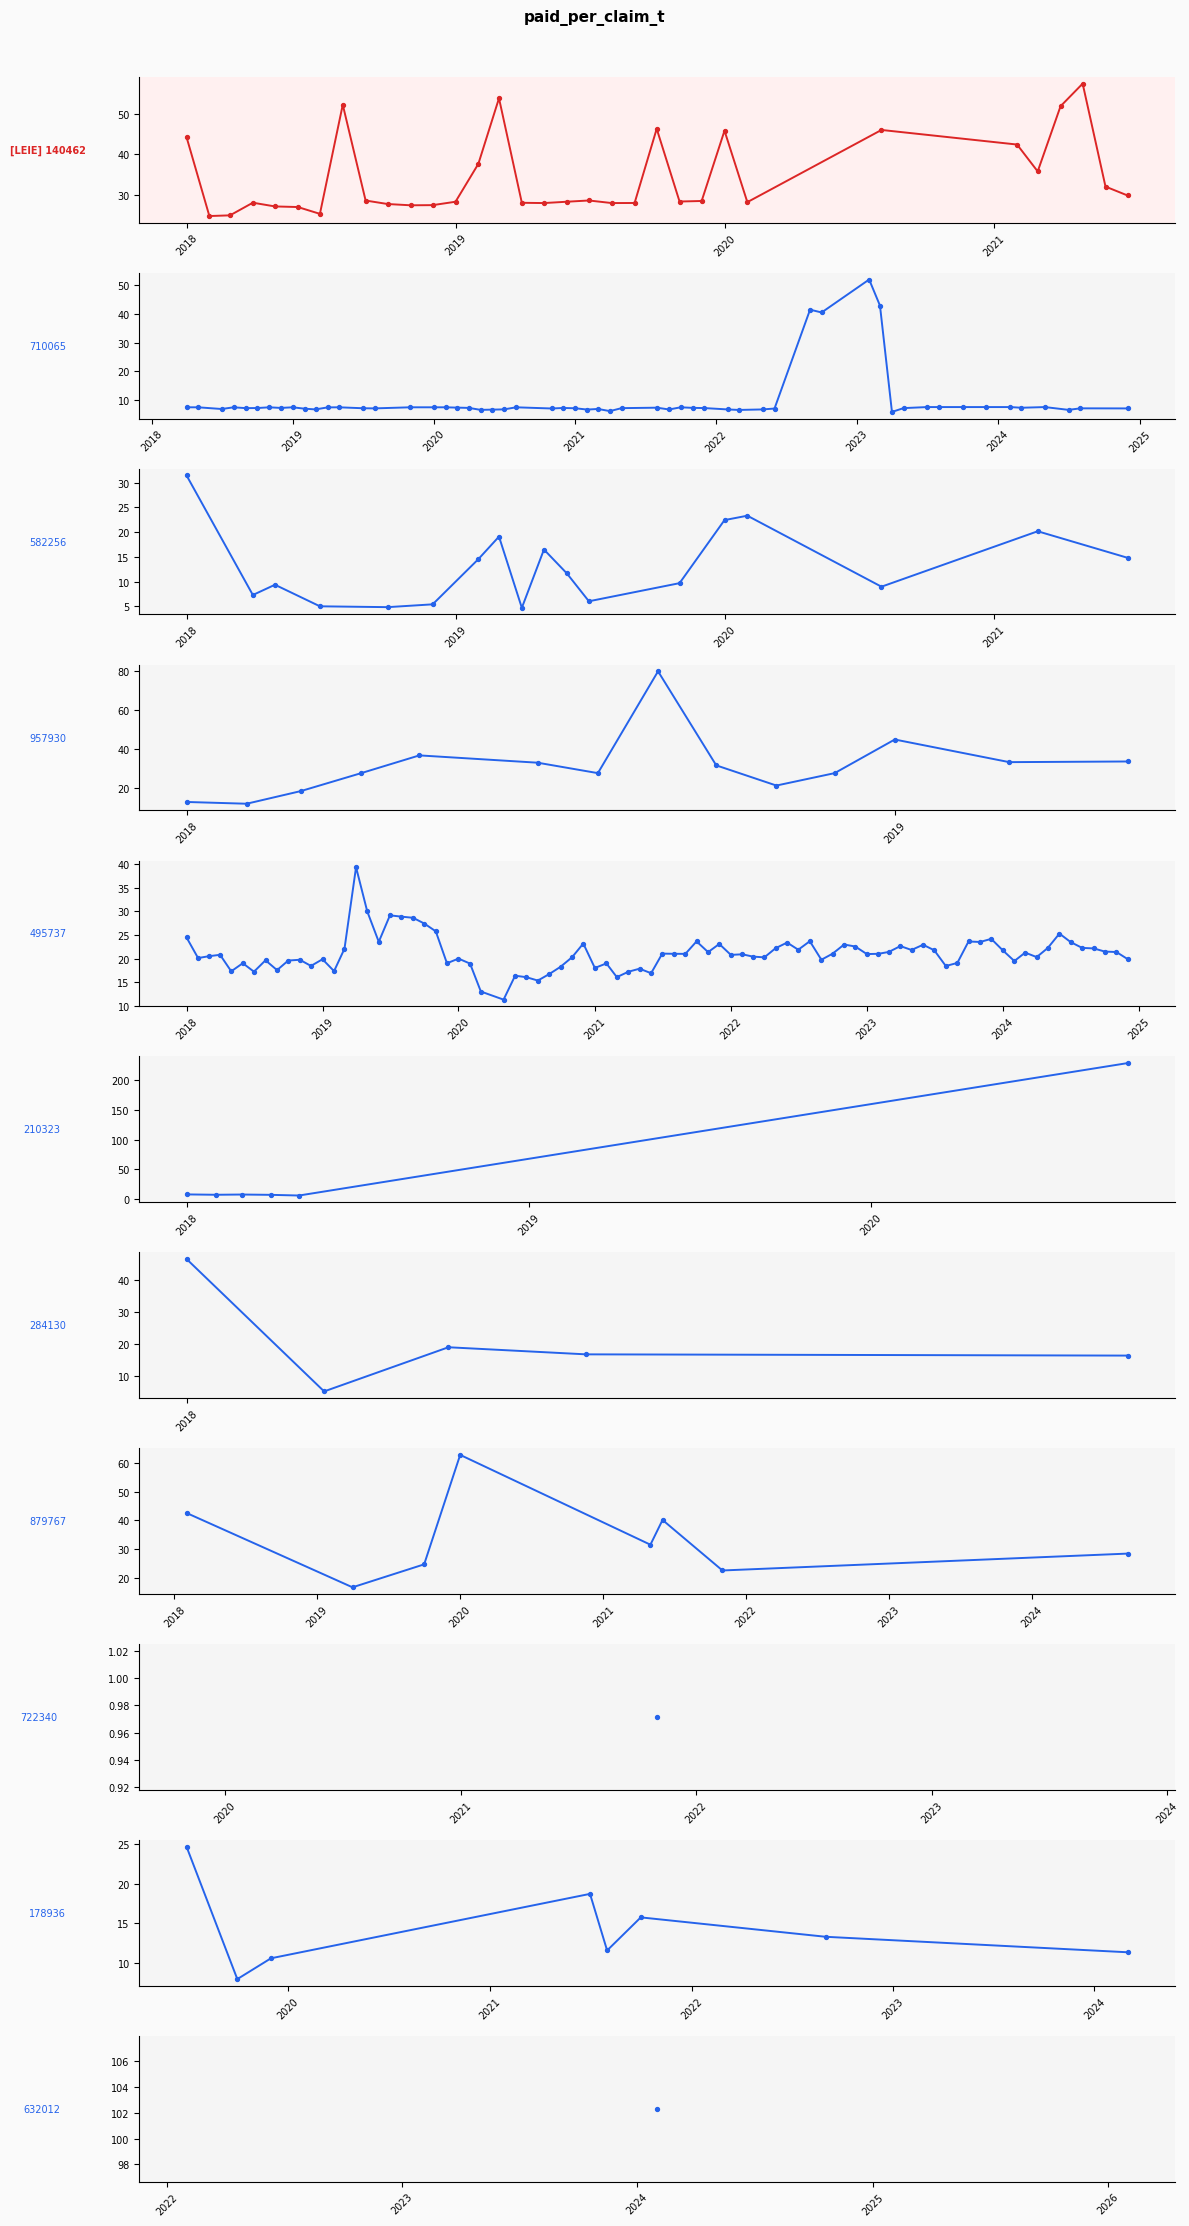

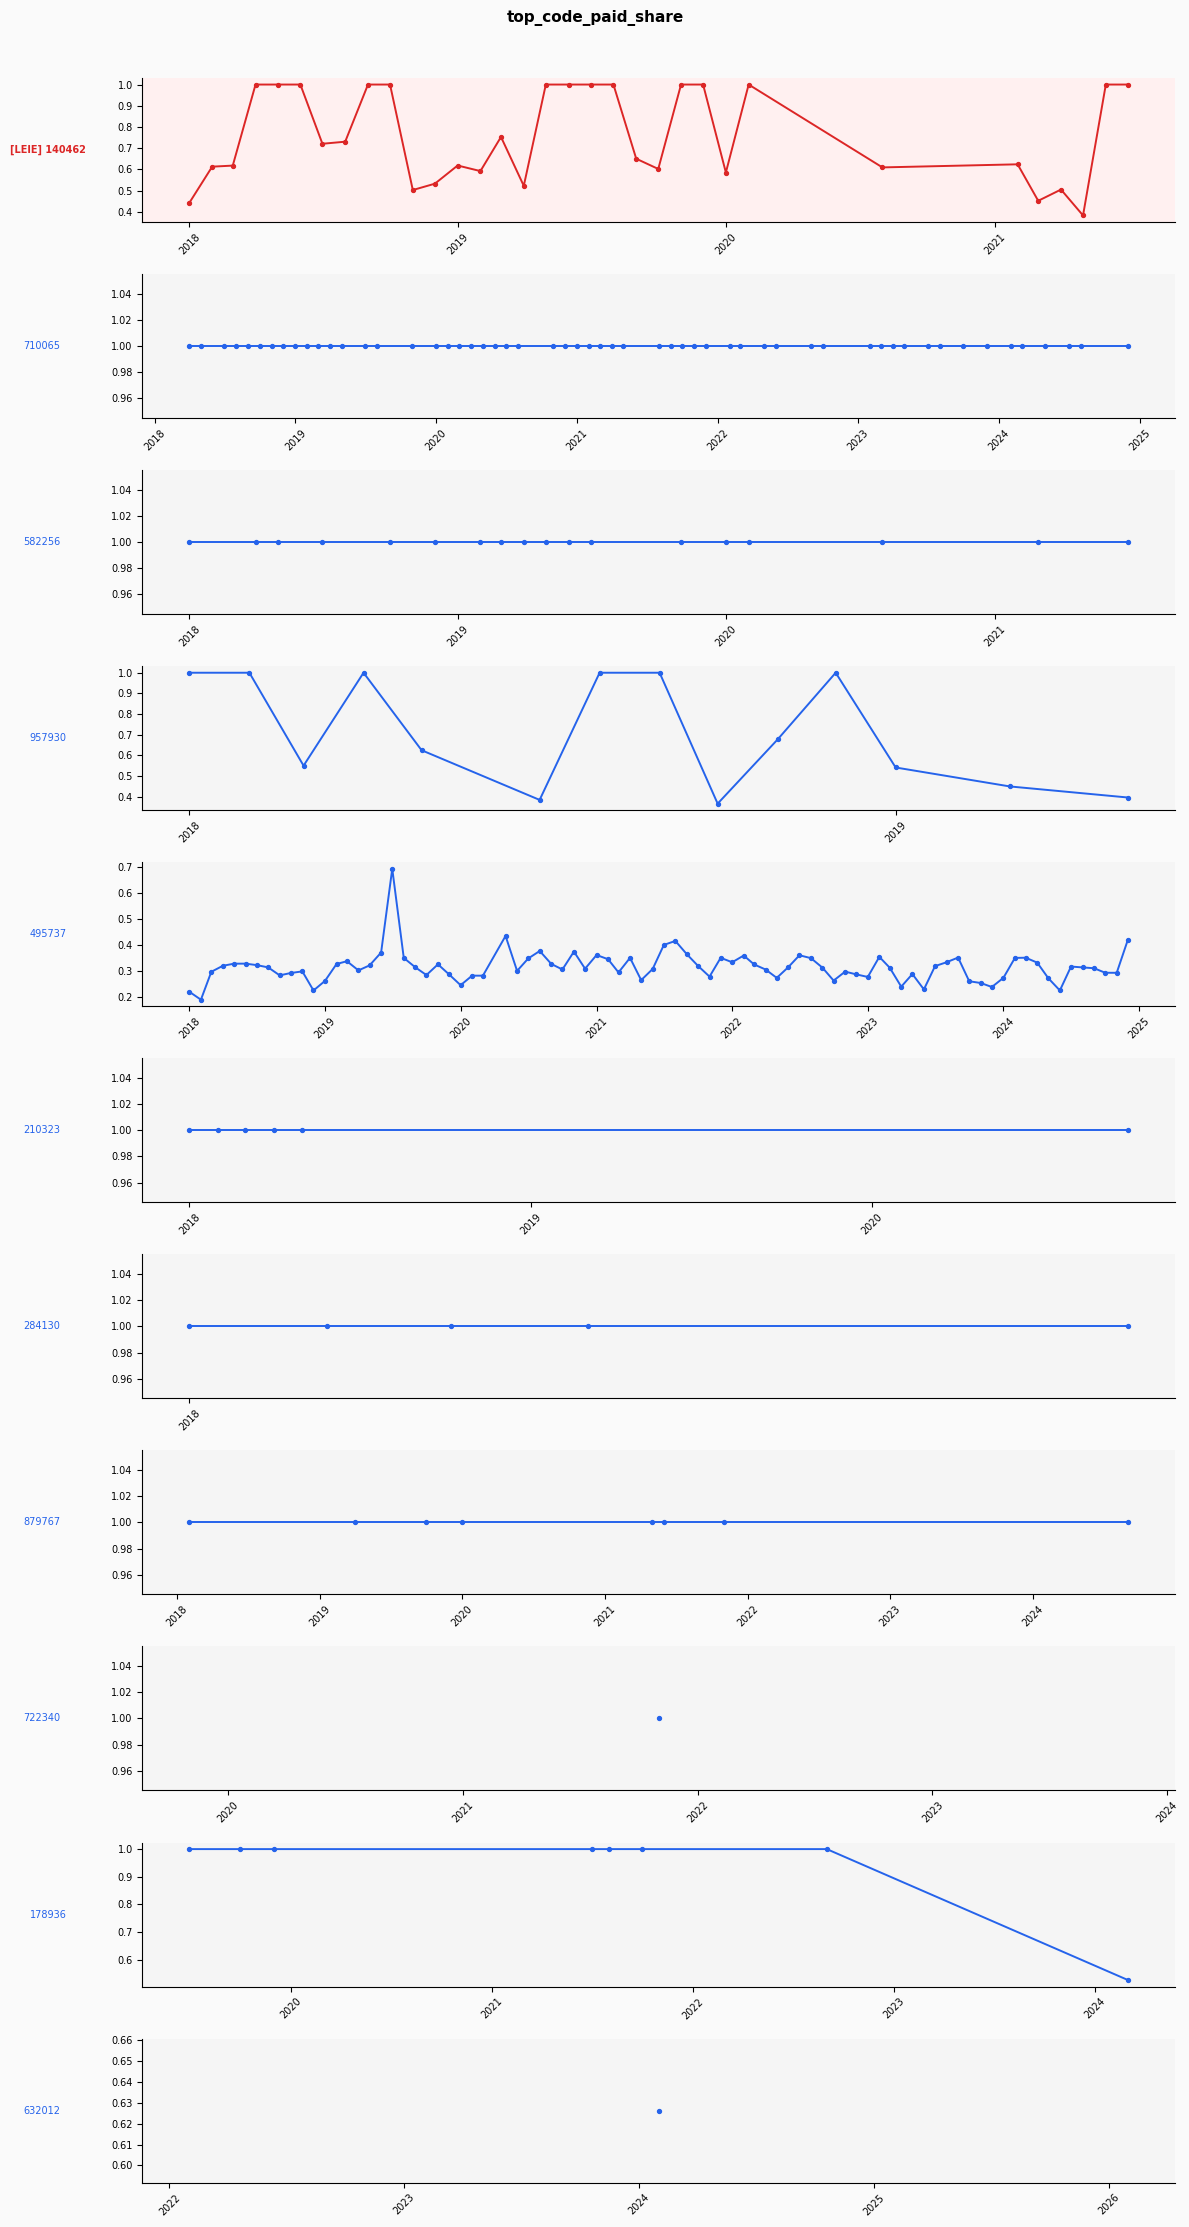

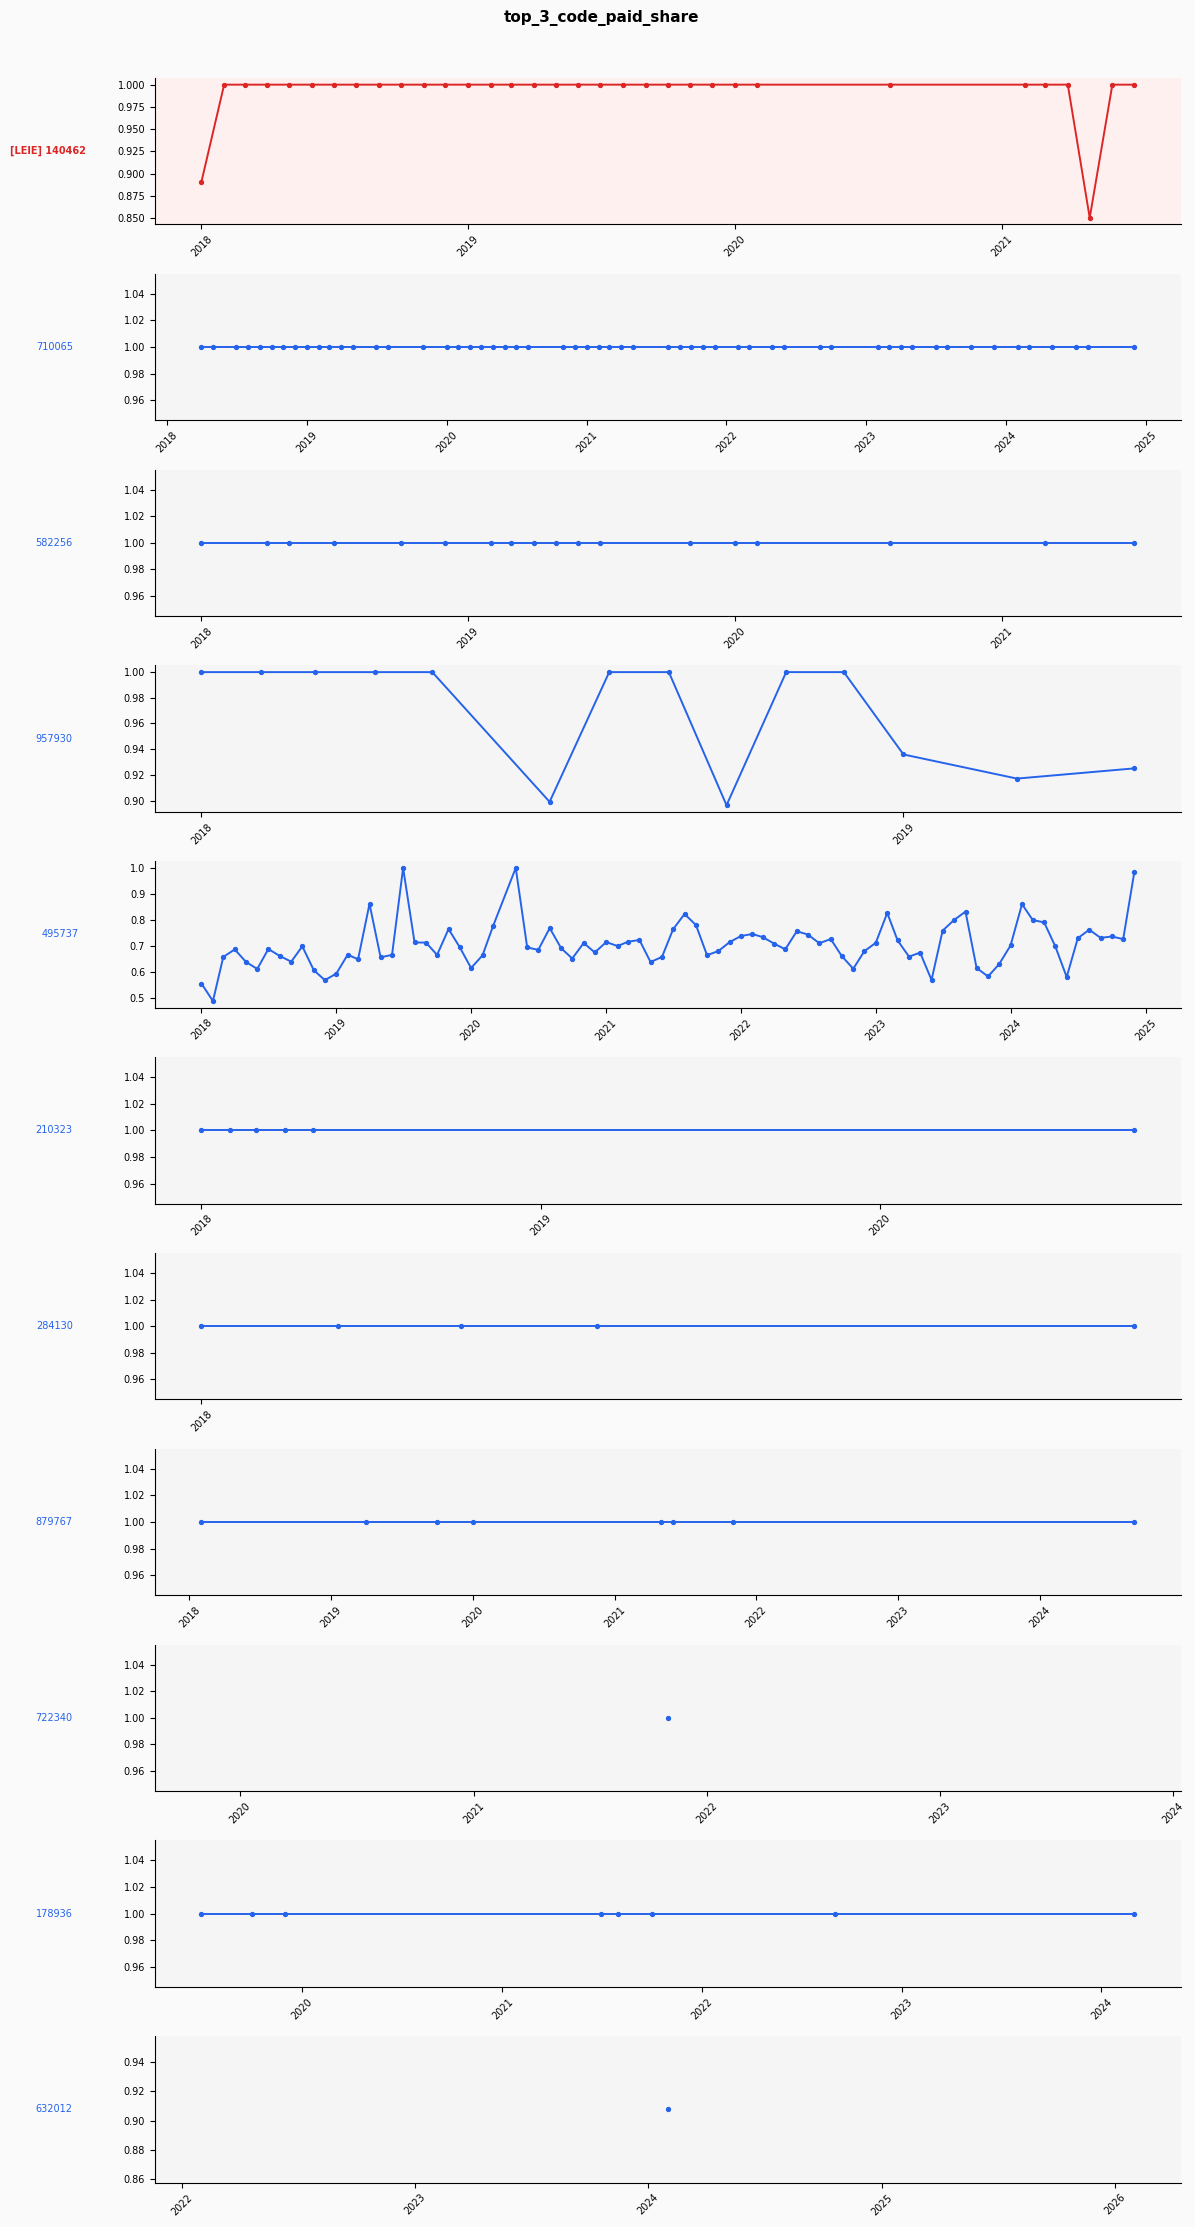

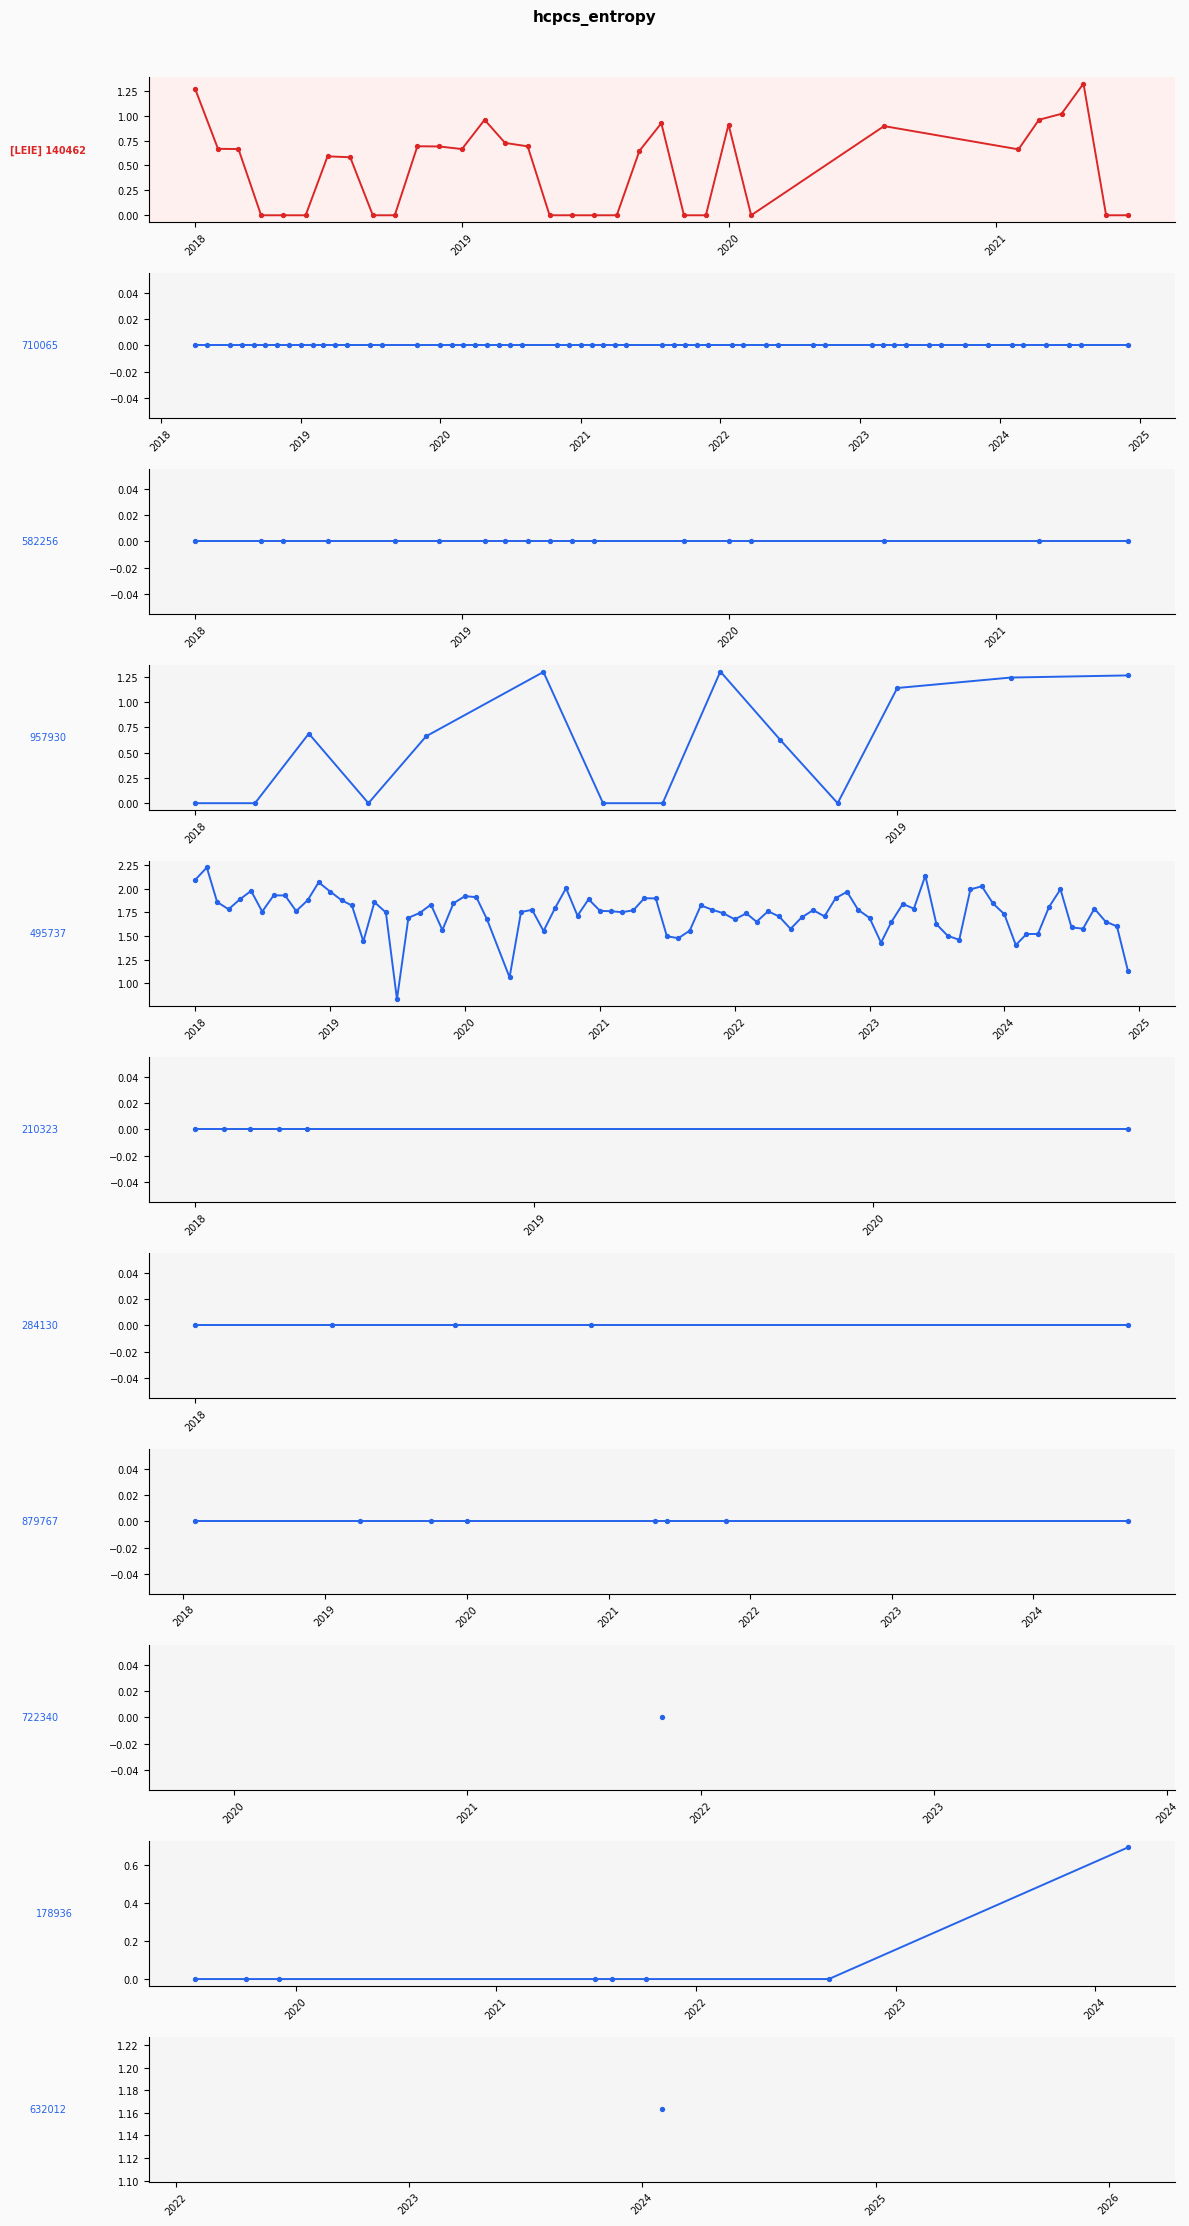

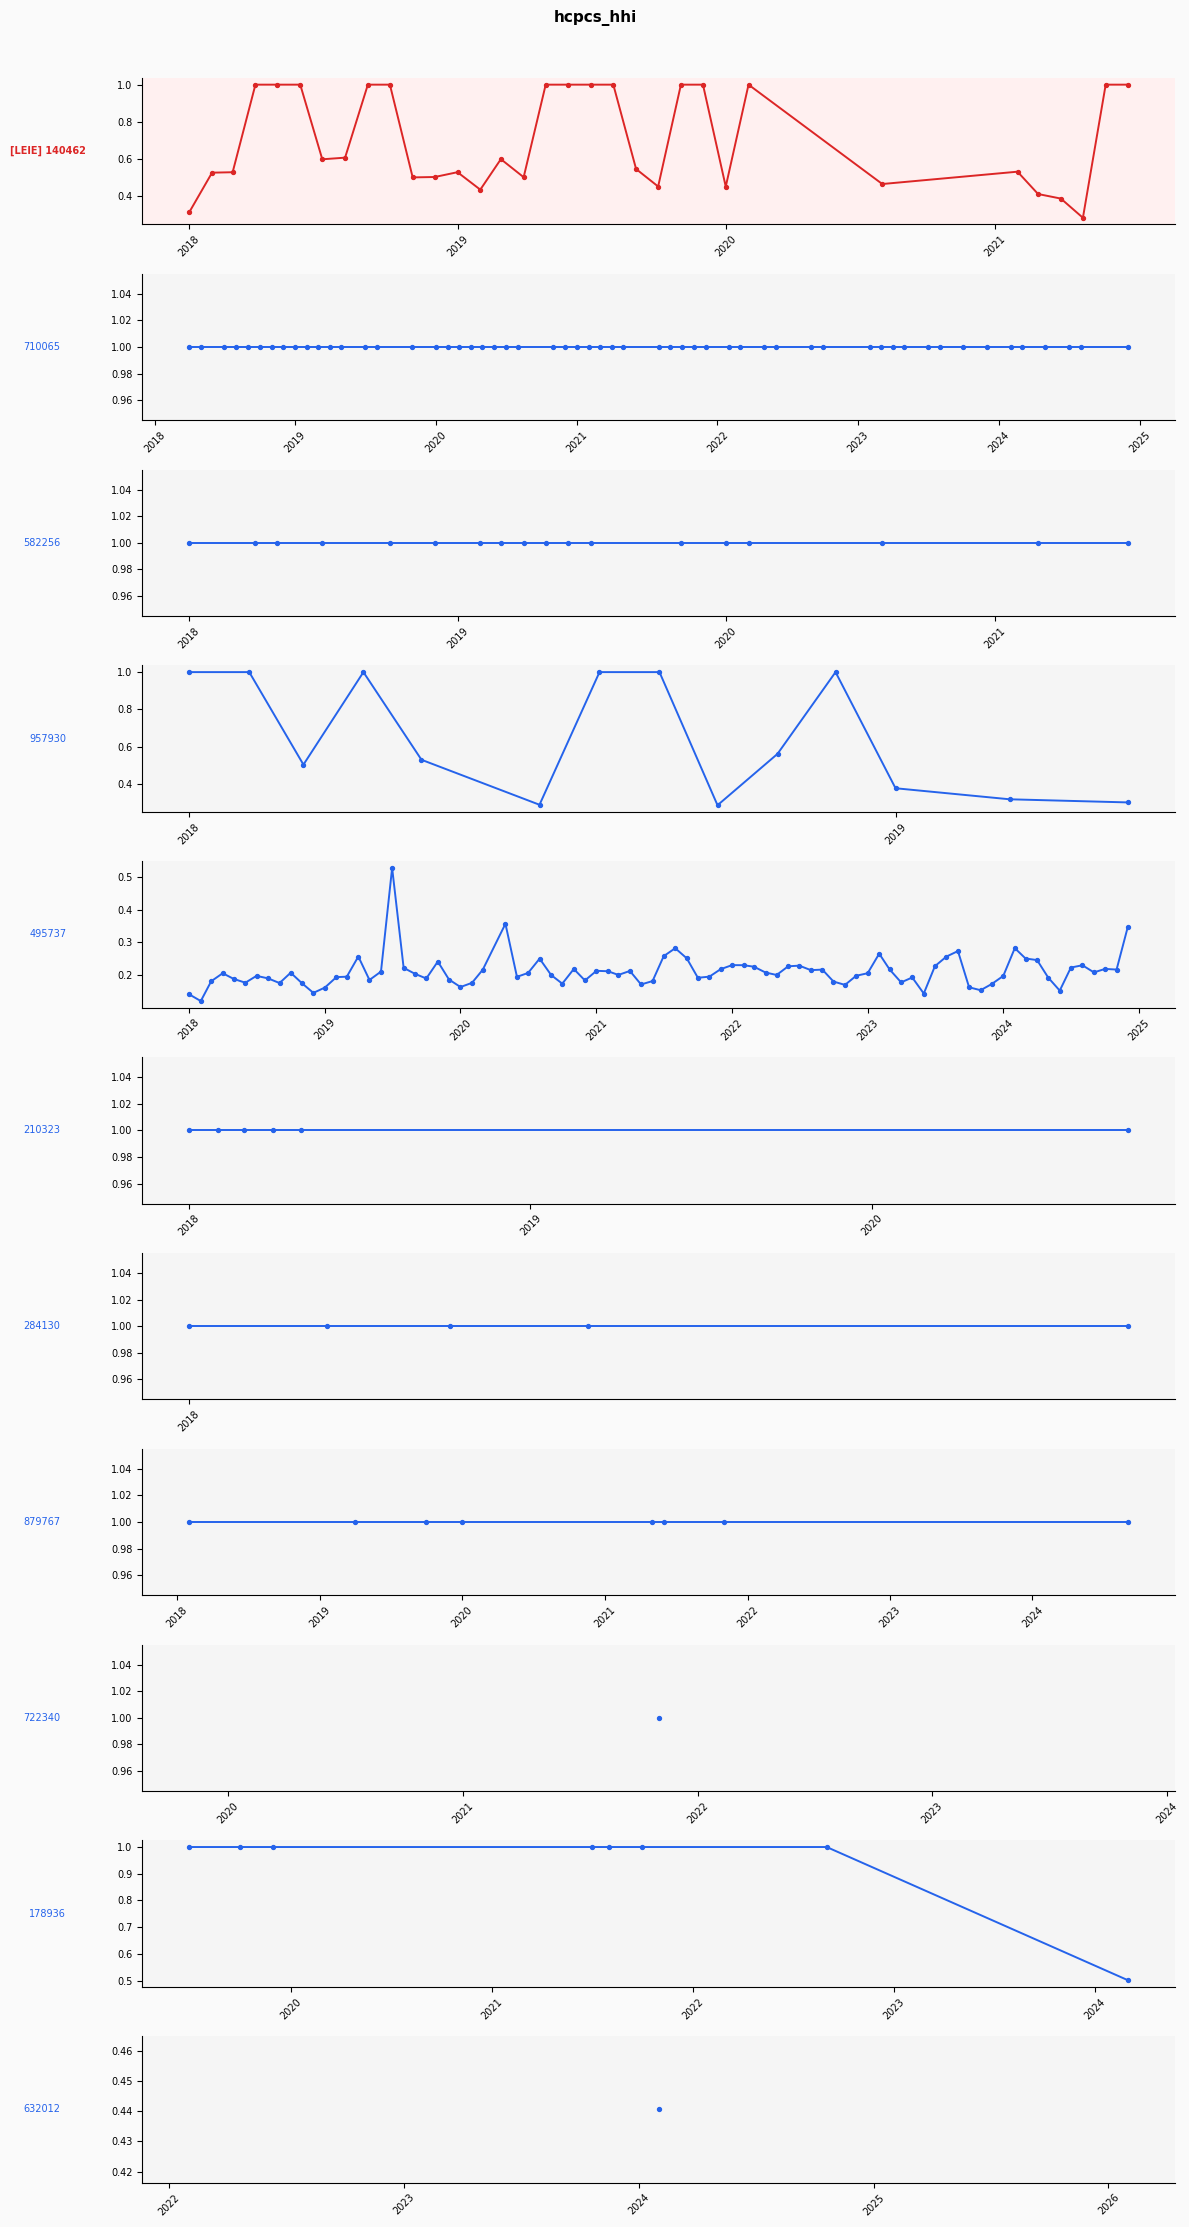

In [2]:
FEATURES = [c for c in df.columns if c not in ("billing_provider_npi", "month", "label", "excldate")]

leie_npis = set(df[df["label"] == 1]["billing_provider_npi"].astype(str).unique())

anomaly_npis = list(leie_npis)
assert len(anomaly_npis) >= 1, "No LEIE providers found in provider_month dataset"
anomaly_npi = str(anomaly_npis[0])

normal_pool = df[df["label"] != 1]["billing_provider_npi"].astype(str).unique()
rng = np.random.default_rng(42)
normal_npis = list(rng.choice(normal_pool, size=10, replace=False).astype(str))

all_npis = [anomaly_npi] + normal_npis
subset = df[df["billing_provider_npi"].astype(str).isin(all_npis)].copy()
subset["month"] = pd.to_datetime(subset["month"])
subset["billing_provider_npi"] = subset["billing_provider_npi"].astype(str)

n_providers = len(all_npis)
n_features  = len(FEATURES)

for col, feat in enumerate(FEATURES):
    fig, axes = plt.subplots(
        n_providers, 1,
        figsize=(12, 2 * n_providers),
        sharex=False,
    )
    fig.patch.set_facecolor("#fafafa")
    fig.suptitle(feat, fontsize=11, fontweight="bold", y=1.01)

    for row, npi in enumerate(all_npis):
        prov = subset[subset["billing_provider_npi"] == npi].sort_values("month")
        is_anomaly = npi in leie_npis
        color = "#dc2626" if is_anomaly else "#2563eb"
        ax = axes[row]
        ax.set_facecolor("#fff0f0" if is_anomaly else "#f5f5f5")
        ax.plot(prov["month"], prov[feat], color=color, lw=1.4)
        ax.scatter(prov["month"], prov[feat], s=8, color=color, zorder=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
        label_str = f"[LEIE] {npi[-6:]}" if is_anomaly else npi[-6:]
        ax.set_ylabel(label_str, fontsize=7, rotation=0, labelpad=50, va="center",
                      color=color, fontweight="bold" if is_anomaly else "normal")

    plt.tight_layout()
    plt.show()